# XGBoost Immunogenicity Predictor

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import joblib
from sklearn.metrics import average_precision_score
from sklearn.metrics import RocCurveDisplay
from utils import save_model
OUTPUT_DIR = "../models"

In [2]:
# Load train / validation / test datasets
dataset_train = pd.read_csv("../data/dataset_train.csv")
dataset_val   = pd.read_csv("../data/dataset_val.csv")
dataset_test  = pd.read_csv("../data/dataset_test.csv")

# Drop non-feature columns
DROP_COLS = ["index", "peptide", "HLA", "hla_sequence"]
TARGET_COL = "Label"

# Split labels
y_train = dataset_train[TARGET_COL].values
y_val   = dataset_val[TARGET_COL].values
y_test  = dataset_test[TARGET_COL].values

# Split features
X_train = dataset_train.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_train.columns])
X_val   = dataset_val.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_val.columns])
X_test  = dataset_test.drop(columns=[TARGET_COL] + [c for c in DROP_COLS if c in dataset_test.columns])

# Combine before one-hot encoding so all splits have matching columns
X_all = pd.concat(
    [X_train, X_val, X_test],
    axis=0,
    keys=["train", "val", "test"]
)

cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"Encoding categorical columns: {cat_cols}")

X_all = pd.get_dummies(X_all, columns=cat_cols)

# Split back
X_train = X_all.loc["train"]
X_val   = X_all.loc["val"]
X_test  = X_all.loc["test"]

print(f"Train: {X_train.shape}, Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val:   {X_val.shape}, Classes: {dict(zip(*np.unique(y_val, return_counts=True)))}")
print(f"Test:  {X_test.shape}, Classes: {dict(zip(*np.unique(y_test, return_counts=True)))}")

print(X_train.columns.tolist())

Encoding categorical columns: []
Train: (5707, 290), Classes: {np.int64(0): np.int64(3143), np.int64(1): np.int64(2564)}
Val:   (1446, 290), Classes: {np.int64(0): np.int64(778), np.int64(1): np.int64(668)}
Test:  (1815, 290), Classes: {np.int64(0): np.int64(991), np.int64(1): np.int64(824)}
['PeptidePos_p1_f1', 'PeptidePos_p1_f2', 'PeptidePos_p1_f3', 'PeptidePos_p1_f4', 'PeptidePos_p1_f5', 'PeptidePos_p1_f6', 'PeptidePos_p1_f7', 'PeptidePos_p1_f8', 'PeptidePos_p1_f9', 'PeptidePos_p1_f10', 'PeptidePos_p1_f11', 'PeptidePos_p1_f12', 'PeptidePos_p1_f13', 'PeptidePos_p1_f14', 'PeptidePos_p1_f15', 'PeptidePos_p1_f16', 'PeptidePos_p1_f17', 'PeptidePos_p1_f18', 'PeptidePos_p2_f1', 'PeptidePos_p2_f2', 'PeptidePos_p2_f3', 'PeptidePos_p2_f4', 'PeptidePos_p2_f5', 'PeptidePos_p2_f6', 'PeptidePos_p2_f7', 'PeptidePos_p2_f8', 'PeptidePos_p2_f9', 'PeptidePos_p2_f10', 'PeptidePos_p2_f11', 'PeptidePos_p2_f12', 'PeptidePos_p2_f13', 'PeptidePos_p2_f14', 'PeptidePos_p2_f15', 'PeptidePos_p2_f16', 'PeptidePo

In [3]:
model = XGBClassifier(
    n_estimators=400,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

model.fit(X_train, y_train)
print("Model trained!!")

Model trained!!


In [4]:
MODEL_NAME = "xgboost_v1"

metadata = {
    "dataset": "dataset_train / dataset_val / dataset_test",
    "features_shape": X_train.shape,
    "notes": "XGBoost with 400 estimators, depth=3, lr=0.05"
}

# Save model
model_path = save_model(
    model=model,
    output_dir=OUTPUT_DIR,
    model_name=MODEL_NAME,
    metadata=metadata
)

Saved model: ../models/xgboost_v1.pkl
Saved metadata: ../models/xgboost_v1_metadata.json


In [5]:
# predict on test set
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)[:, 1]


test_acc = accuracy_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("Test Accuracy:", round(test_acc, 4))
print("Test ROC-AUC:", round(test_auc, 4))

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.7928
Test ROC-AUC: 0.8715

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.77      0.80       991
           1       0.75      0.82      0.78       824

    accuracy                           0.79      1815
   macro avg       0.79      0.79      0.79      1815
weighted avg       0.80      0.79      0.79      1815



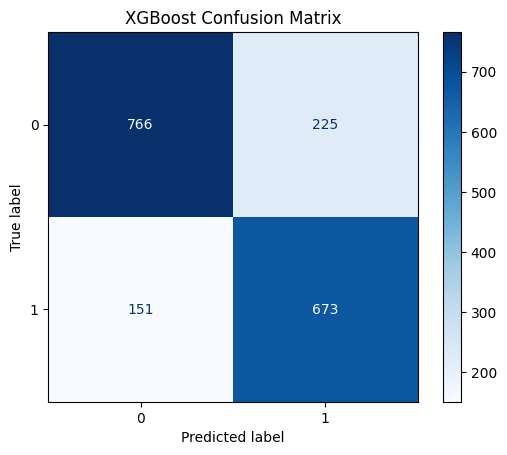

In [6]:
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [7]:
test_auprc = average_precision_score(y_test, y_test_prob)
print("Test AUPRC:", round(test_auprc, 4))

Test AUPRC: 0.8164


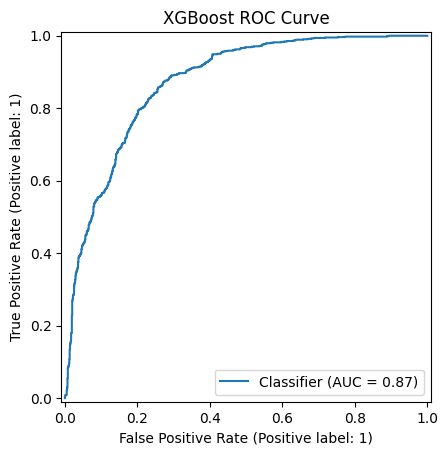

In [8]:
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("XGBoost ROC Curve")
plt.show()

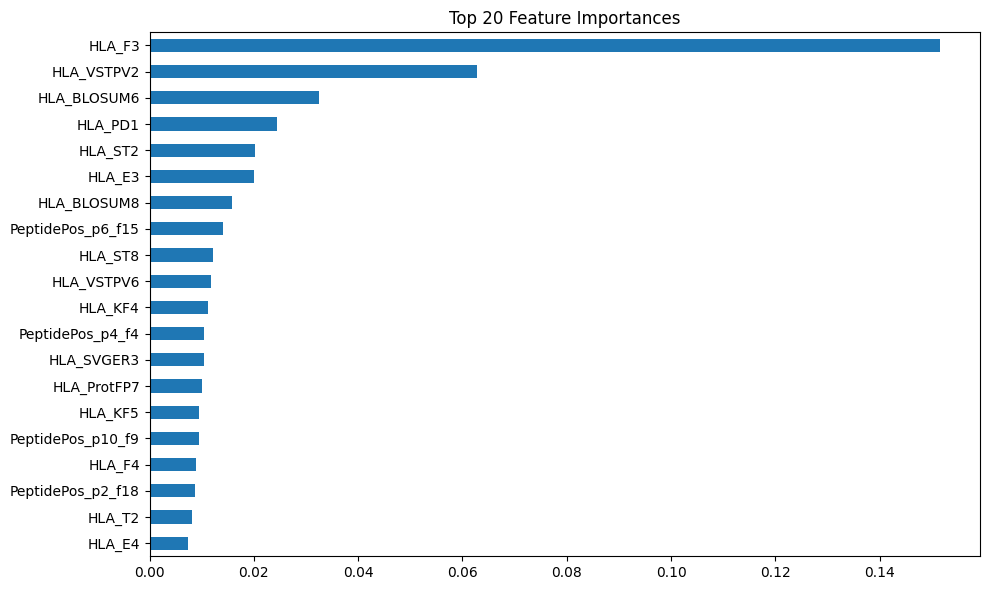

In [9]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(20).plot(kind="barh", figsize=(10, 6))

plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

## XGBoost Random Search

In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from scipy.stats import randint, uniform
import os

In [11]:
# parameter space
param_dist = {
    "n_estimators": randint(300, 1000),
    "max_depth": randint(3, 7),
    "learning_rate": uniform(0.01, 0.09),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 2)
}


In [12]:
n_trials = 30
start_v = 2

results = []

for i in range(n_trials):
    version = f"v{start_v + i}"

    # sample parameters
    params = {k: v.rvs() for k, v in param_dist.items()}

    # add fixed parameters
    params.update({
        "random_state": 42,
        "eval_metric": "logloss",
        "use_label_encoder": False
    })

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)

    # validation performance
    y_val_prob = model.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, y_val_prob)

    print(f"xgboost_{version} | AUC: {val_auc:.4f}")

    # save model using save_model()
    save_model(
        model=model,
        output_dir="../models",
        model_name=f"xgboost_{version}",
        metadata={
            "dataset": "dataset_train / dataset_val / dataset_test",
            "features": X_train.columns.tolist(),
            "params": model.get_params(),
            "version": version,
            "val_auc": val_auc,
            "notes": "XGBoost random search model"
        }
    )

    results.append({
        "version": version,
        "val_auc": val_auc,
        **params
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("val_auc", ascending=False)

display(results_df)

best_row = results_df.iloc[0]
print("\nBest XGBoost random-search model:")
print(best_row)

xgboost_v2 | AUC: 0.8740
Saved model: ../models/xgboost_v2.pkl
Saved metadata: ../models/xgboost_v2_metadata.json
xgboost_v3 | AUC: 0.8770
Saved model: ../models/xgboost_v3.pkl
Saved metadata: ../models/xgboost_v3_metadata.json
xgboost_v4 | AUC: 0.8832
Saved model: ../models/xgboost_v4.pkl
Saved metadata: ../models/xgboost_v4_metadata.json
xgboost_v5 | AUC: 0.8765
Saved model: ../models/xgboost_v5.pkl
Saved metadata: ../models/xgboost_v5_metadata.json
xgboost_v6 | AUC: 0.8755
Saved model: ../models/xgboost_v6.pkl
Saved metadata: ../models/xgboost_v6_metadata.json
xgboost_v7 | AUC: 0.8757
Saved model: ../models/xgboost_v7.pkl
Saved metadata: ../models/xgboost_v7_metadata.json
xgboost_v8 | AUC: 0.8717
Saved model: ../models/xgboost_v8.pkl
Saved metadata: ../models/xgboost_v8_metadata.json
xgboost_v9 | AUC: 0.8724
Saved model: ../models/xgboost_v9.pkl
Saved metadata: ../models/xgboost_v9_metadata.json
xgboost_v10 | AUC: 0.8793
Saved model: ../models/xgboost_v10.pkl
Saved metadata: ../mode

,version,val_auc,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,gamma,random_state,eval_metric,use_label_encoder
2,v4,0.883224,409,6,0.062933,0.782984,0.839409,0.498108,42,logloss,False
8,v10,0.879272,380,6,0.055793,0.902454,0.750406,0.022343,42,logloss,False
22,v24,0.878410,686,6,0.030366,0.913591,0.835762,0.584543,42,logloss,False
11,v13,0.877608,812,5,0.054791,0.876512,0.723806,0.698552,42,logloss,False
1,v3,0.876959,890,6,0.060013,0.821406,0.721750,0.870882,42,logloss,False
3,v5,0.876501,822,6,0.086421,0.986257,0.724657,0.308125,42,logloss,False
24,v26,0.876468,817,6,0.098585,0.765682,0.804810,0.394716,42,logloss,False
25,v27,0.876395,571,5,0.079618,0.795368,0.921553,0.412240,42,logloss,False
28,v30,0.876285,581,4,0.093645,0.737666,0.925307,1.372187,42,logloss,False
5,v7,0.875685,703,6,0.048571,0.938969,0.796919,1.417256,42,logloss,False



Best XGBoost random-search model:
version                    v4
val_auc              0.883224
n_estimators              409
max_depth                   6
learning_rate        0.062933
subsample            0.782984
colsample_bytree     0.839409
gamma                0.498108
random_state               42
eval_metric           logloss
use_label_encoder       False
Name: 2, dtype: object
